# Reptile Object Detection using YOLOv8

Dataset:
- 419 images
- 4 classes: crocodile, frog, lizard, snake
- Split: 280 train, 87 valid, 52 test

Objective:
Evaluate YOLOv8 performance on small-scale reptile dataset.

In [1]:
from ultralytics import YOLO
import torch
import matplotlib.pyplot as plt
import pandas as pd
import os

In [2]:
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch version: 2.10.0+cu126
CUDA available: True
GPU: NVIDIA GeForce MX230


In [3]:
#Train YOLO
model = YOLO('yolov8n.pt')
results = model.train(
    data="dataset/data.yaml",
    epochs=100,
    imgsz=640,
    batch=4,
    device=0
)


Ultralytics 8.4.14  Python-3.12.4 torch-2.10.0+cu126 CUDA:0 (NVIDIA GeForce MX230, 2048MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0,

In [4]:
#Eval model
metrics = model.val(data="dataset/data.yaml")
print(metrics)

Ultralytics 8.4.14  Python-3.12.4 torch-2.10.0+cu126 CUDA:0 (NVIDIA GeForce MX230, 2048MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.20.0 ms, read: 111.647.2 MB/s, size: 32.5 KB)
val: Scanning D:\ILKOM\SM 6\reptile-detection\dataset\valid\labels.cache... 87 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 87/87  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 6.3s/it 38.0s1.0ss3
                   all         87         93      0.891      0.737      0.869       0.48
             crocodile         17         19      0.855      0.737      0.874      0.489
                  frog         18         20      0.973       0.75      0.923       0.58
                lizard         25         27      0.916      0.778      0.841      0.401
                 snake         27         27      0.821      0.682      0.837      0.451
Speed: 5.8ms preprocess, 26.6

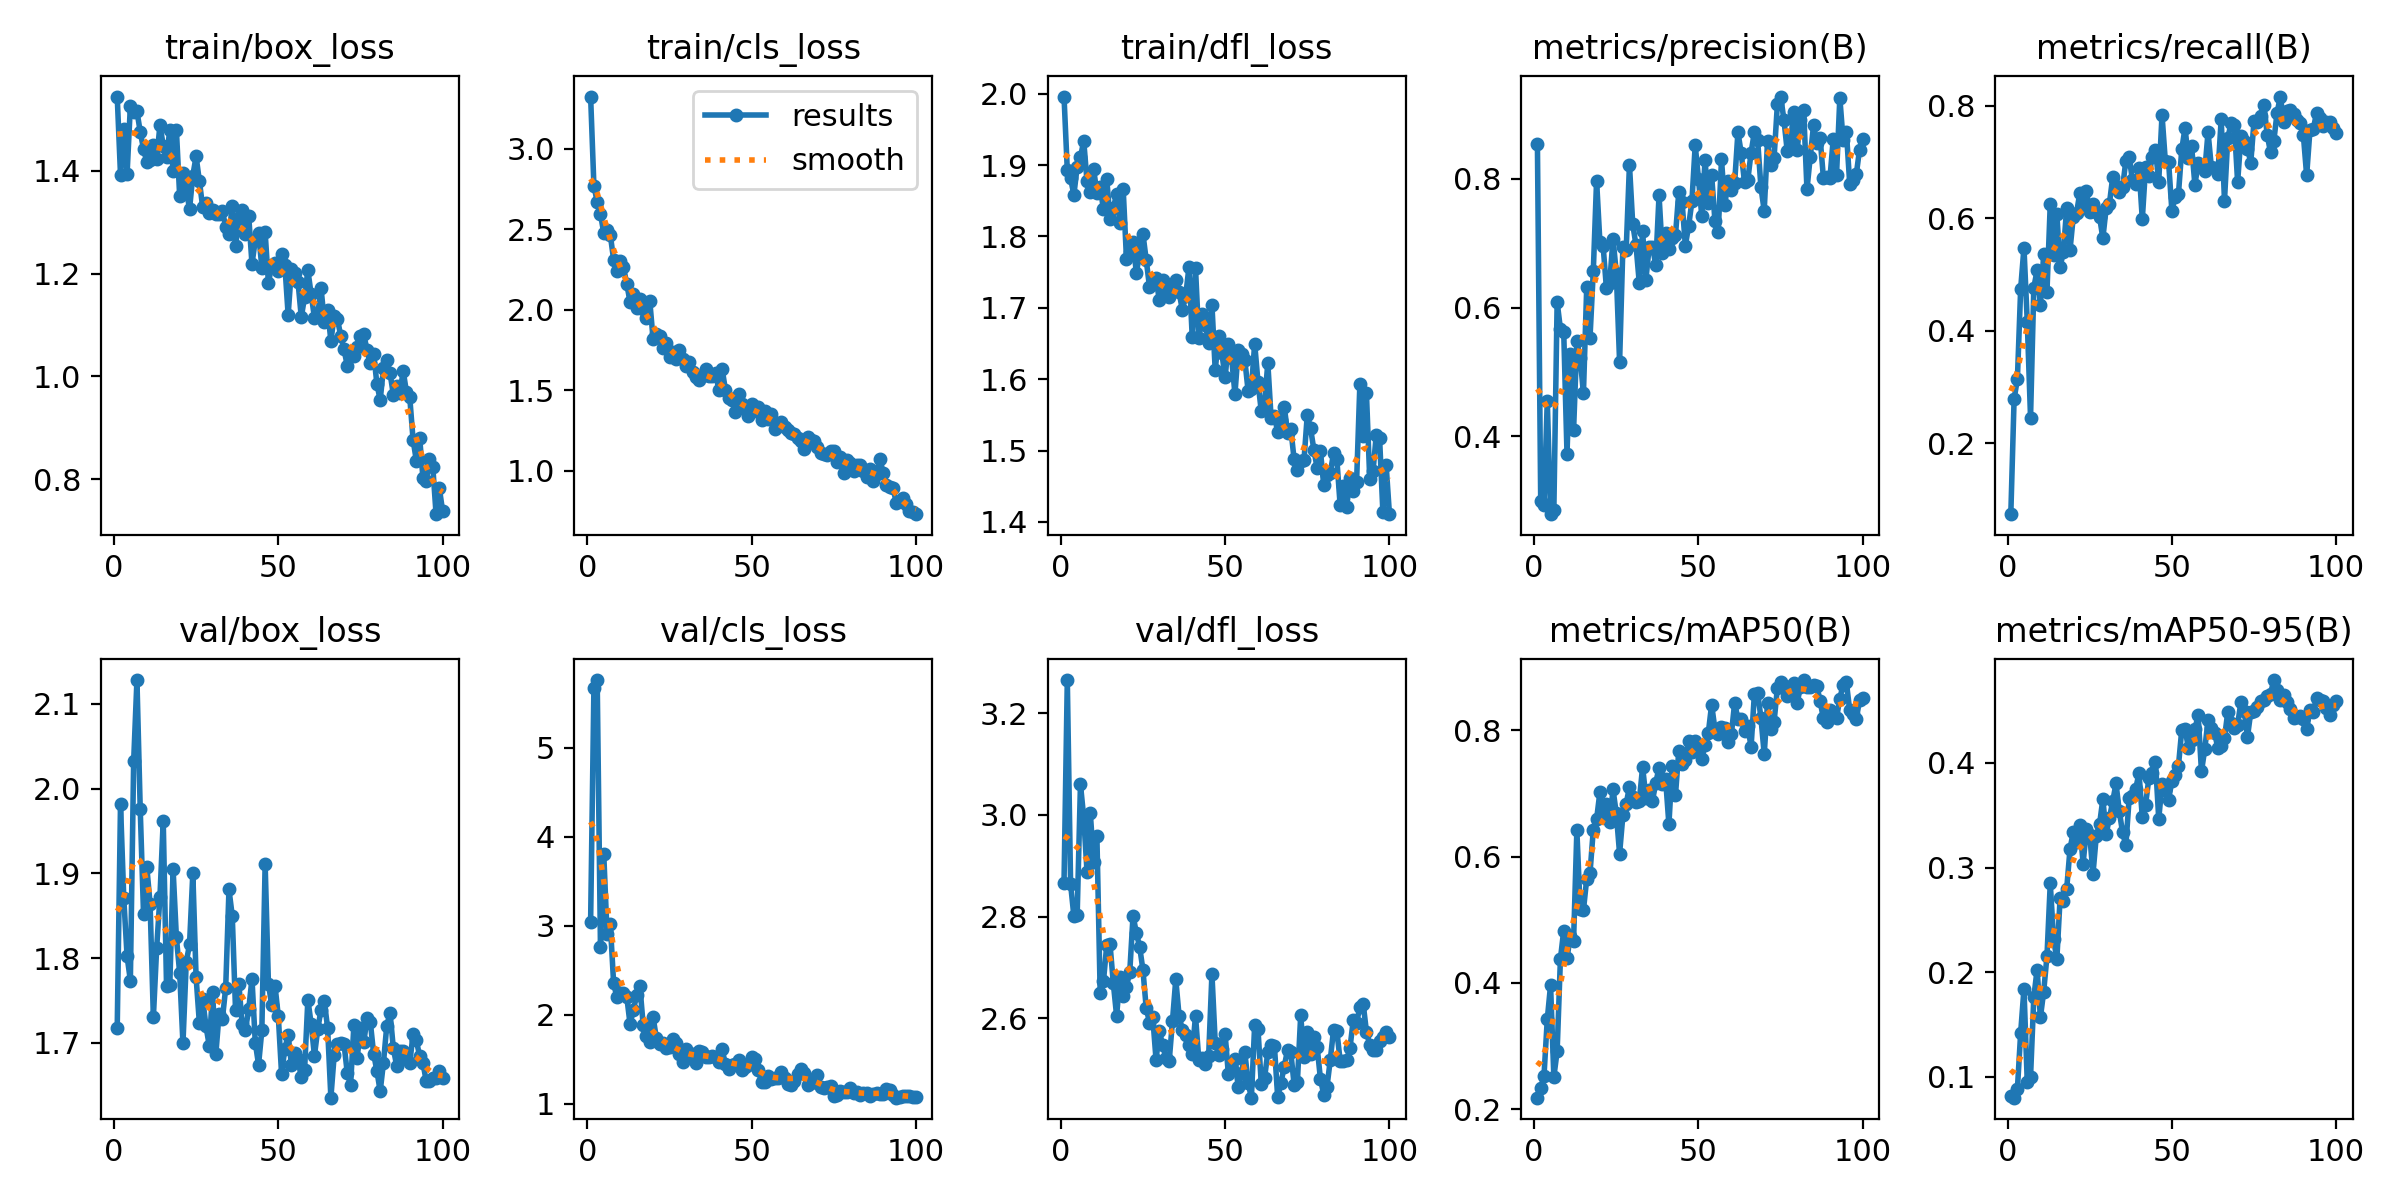

In [5]:
from IPython.display import Image
import os

save_dir = "runs/detect/train3"

Image(filename=os.path.join(save_dir, "results.png"))


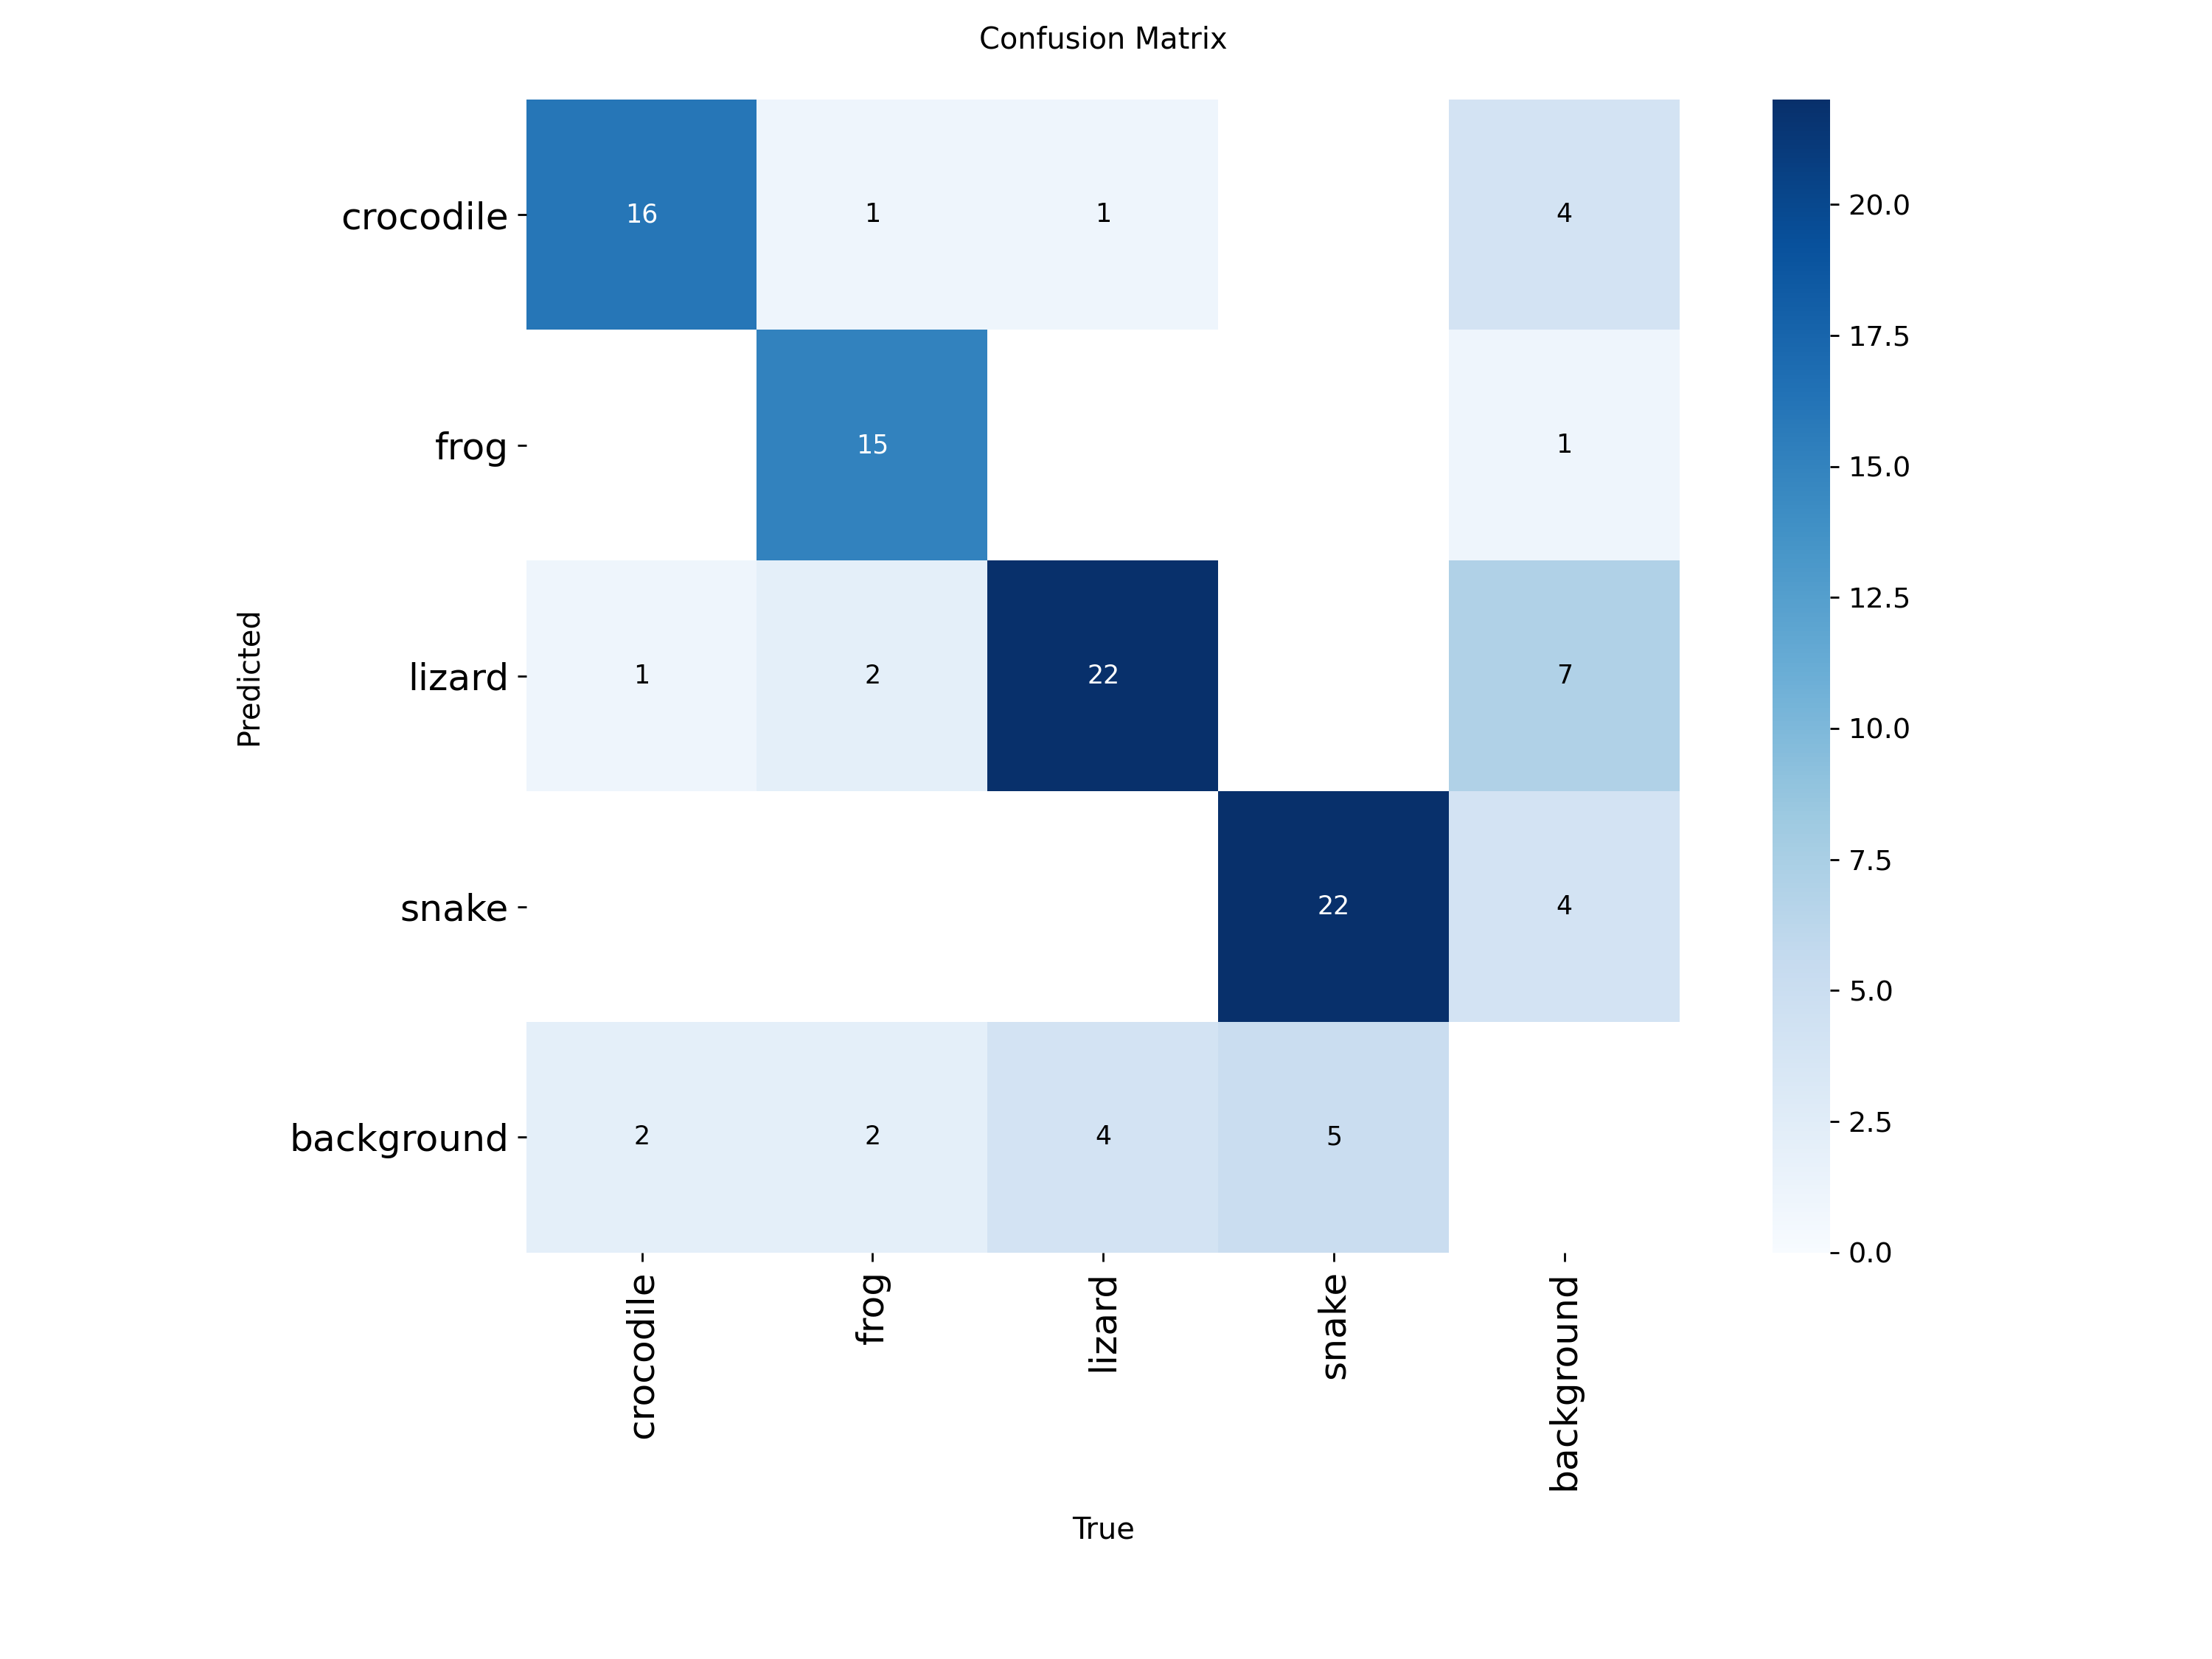

In [6]:
Image(filename=os.path.join(save_dir, "confusion_matrix.png"))